# UAV Digital Twin for Communication Optimization

## About
This simulation combines:
* OpenStreetMaps Data
* Sionna Ray Tracing
* Simulation of Urban MObility (SUMO)
* Custom UAV Control Framework

To produce a digital twin that can be used for training a reinforcement learning model to optimize the locations of UAVs for their communication with the ground users.

## Functionality
This digital twin provides functionality for:
* Loading scene data from an OpenStreetMaps export
* Loading pedestrian data from a SUMO export
* Adding and controlling UAV devices
* Calculating UAV energy consumption based on movements
* Moving pedestrian positions
* Computing the signal quality for a given simulation state
* Visualizing scenes, UAVs, ground users, paths, and coverage maps

## What's Next
The biggest thing that the simulation is missing is more concreteness with the computation of the path quality. It would be better to measure another quantity, like throughput, which is more grounded in the real world than some arbitrary comparitive measure of path quality.

# Digital Twin Demonstration
This notebook runs through some of the features of the digital twin, and how to implement features of the digital twin. As you read through, please experiment with the parameters to see if the digital twin meets the needs of your project.

## Creating the Environment
* The environment is the single container for the digital twin simulation. It should be a singleton instance and most all function calls should be made through the environment instance.
* The environment creation takes arguments to the data from Mitsuba Blender and SUMO to construct the scene and ground users, respectively.
* It also takes some parameters about the time granularity, assumed pedestrian height, receivers, and the wind.

In [1]:
# Importing the Framework and other important libraries
# Don't worry too much about the warnings. They are mostly about CUDA optimizations
import sionna
import numpy as np
import drjit as dr
import mitsuba as mi
import tensorflow as tf
import matplotlib.pyplot as plt
from EnvironmentFramework import Environment, UAV, GroundUser
from sionna.rt import PlanarArray, PathSolver, Transmitter, Receiver

2025-09-08 15:58:59.626812: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-08 15:58:59.639055: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757361539.652685   47909 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757361539.656613   47909 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1757361539.666209   47909 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# Checking If GPU is Enabled
* Sionna supports running through both GPU and CPU-only execution
* GPU-enabled computatations greatly accelerate Sionna methods and computations, so if your computer has a GPU, you should try to configure it
* If the GPU is not connected as shown in the following cell, follow the steps on the ReadMe to configure it
* If a GPU is not found, there are additional set-up instructions in the ReadMe about how to configure Sionna for CPU-only execution

In [2]:
if len(tf.config.list_physical_devices("GPU")) > 0:
    print("GPU Found!")
else:
    print("No GPU Detected...")

GPU Found!


In [3]:
# Loading the environment data from the Mitsuba Blender Export
# This is just the basic scene import, before using any of the RL-DT Tools
env = sionna.rt.load_scene('../data/RaleighUnionSquareStandardReference/raleigh_union_square.xml')
env.preview()

Renderer(camera=PerspectiveCamera(aspect=1.31, children=(DirectionalLight(intensity=0.25, position=(0.0, 0.0, …

In [4]:
# Creating the RL-DT environment with building topology and pedestrian position data
# Then using the built-in visualization function to inspect the scene
env = Environment('../data/RaleighUnionSquareStandardReference/raleigh_union_square.xml',
                  "../data/simulated_final_person_new.csv",
                  delta_t=1, ped_height=1.5, ped_rx=True, wind_vector=np.zeros(3))
env.visualize()

## Visualizing the Environment
* The scene.preview function is the primary way to see the scene.
* It can be used to see UAVs, Ground Users, traced paths, and coverage maps

In [5]:
# Default visualization with no provided paths or radio map
env.visualize(paths=None, radio_map=None)

In [6]:
# Adding a UAV to the scene in the middle above the city
id = env.addUAV(pos=np.array([0, 0, 100]))
ids = [id]
env.visualize()

## Visualizing Ground Users
* Because the ground users can sometimes be difficult to see among the buildings, you can visualize their distribution seperately with the plotGUs function.
* This function returns a 2D plot of the Ground Users in x and y.
* This could be used to look for clusters or patterns in the Ground Users, for some UAV positioning algorithms

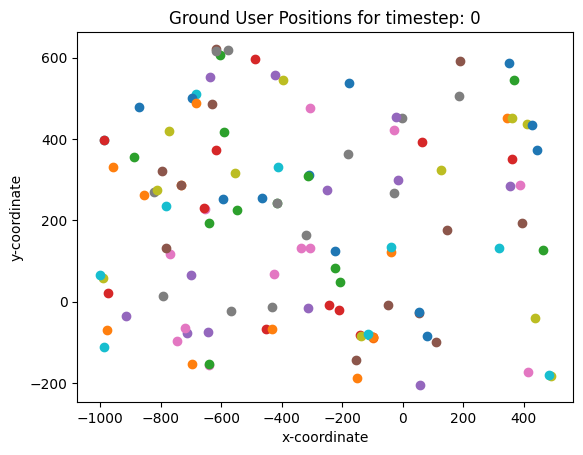

In [7]:
# Providing no arguments utilizes the current timestep, or you can provide one with the 'timestep' keyword
env.plotGUs()

## Instantiating Test UAVs
* The UAV supports an unlimited number of UAVs, but it is easier to visualize the changes in path quality and consumption for just a few devices.
* Building the UAVs requires an initial unique id, mass, efficiency, position, velocity, bandwidth, and rotor area
* The efficiency measure the amount of energy goes towards movement, instead of being lost to heat
* The rotor area is used for the calculation of the hovering energy cost. A higher rotor area means that the UAV uses less energy to hover.

In [8]:
# We'll define 4 stationary UAVs in a square around the central UAV device that we have already configured
id1 = env.addUAV(mass=10, efficiency=0.8, pos=np.array([0, -500, 100]), vel=np.zeros(3), bandwidth=50, 
                 rotor_area=0.5, signal_power=3)
id2 = env.addUAV(mass=10, efficiency=0.8, pos=np.array([500, 0, 100]), vel=np.zeros(3), bandwidth=50, 
                 rotor_area=0.5, signal_power=3)
id3 = env.addUAV(mass=10, efficiency=0.8, pos=np.array([0, 500, 100]), vel=np.zeros(3), bandwidth=50, 
                 rotor_area=0.5, signal_power=3)
id4 = env.addUAV(mass=10, efficiency=0.8, pos=np.array([-500, 0, 100]), vel=np.zeros(3), bandwidth=50, 
                 rotor_area=0.5, signal_power=3)
ids += [id1, id2, id3, id4]

In [9]:
# Then preview the scene using the visualize method
env.visualize()

## Initializing the Antenna Arrays
* Before we can use the radio maps or path computations, we need to tell Sionna what kind of antennas to use.
* There is a default isotropic antenna configuration, or you can make you own custom antennas

In [10]:
# Using the default isotropic antenna configuration
env.setTransmitterArray()  # For the UAVs
env.setReceiverArray()  # For the Ground Users

## Testing Radio Maps
* Now that we have some UAVs (Transmitters) and Ground User (Receivers), we can utilize Sionna to generate radio maps that model the communication quality on the Ground with respect to the UAV devices
* First, we must

In [11]:
# Making each of the UAV's antennas point at the ground
for i in ids:
    env.uavs[i].lookAt()

# We generate the radio map using env.computeRadioMap, then use the visualize method to look at it
radio_map = env.computeRadioMap(max_depth=2, num_samples=10000000, cell_size=(1,1))
    
env.visualize(radio_map=radio_map)

# Interpreting Radio Maps
* The lighter green sections represent areas that have better signal, and the darker regions have less signal
* From the visualization, we can clearly see the antenna directions towards the lighter green sides
* Additionally, we see shadows of buildings where the LoS paths are not able to reach
* Finally, the computation is heavily expidited by Just-In-Time compilation and even quicker with a CUDA-enabled GPU!

# Radio Map Application
* Radio Maps can be used to calculate SINR or other metrics for each receiver in the scene
* They can also be used to assign transmitters (UAVs) to cells and therefore to receivers (Ground Users) as well
* In the following cell, we show how to use radio maps to quickly compute the SINR for each Ground User in the scene

In [12]:
# Flushing the cache
dr.flush_malloc_cache()

# Generating a new radio map
radio_map = env.computeRadioMap(max_depth=2, num_samples=1000000, cell_size=(5.0, 5.0))

# Grabbing the SINR values for each Ground User
sinrs = np.sum(env.getUserSINR(radio_map), axis=1)  # Summing the Transmitters for the time being, use diversity combining later

n_rx = 118
indices = radio_map.rx_cell_indices.numpy().T
rtn = np.empty(shape=n_rx)
for i in range(n_rx):
    rtn[i] = np.sum(radio_map.sinr[:, int(indices[i][0]), int(indices[i][1])])

# Verifying that the cell centers are close to the pedestrian positions
cell_positions = [radio_map.cell_centers[int(i[1]), int(i[0]), :] for i in indices]
ped_pos = [x.device.position for x in env.gus]
max_dist = 0
for i in range(n_rx):
    a = cell_positions[i].numpy()
    b = ped_pos[i].numpy().flatten()
    max_dist = max(np.linalg.norm(a - b), max_dist)
print(f"The farthest distance from user to cell center is {max_dist}, which is small and expected")
    
# Performing a visualization by log-normalizing and encoding in the GU colors
sinrs = np.maximum(np.log(sinrs), np.zeros(len(sinrs)));
sinrs_normalized = (sinrs - np.min(sinrs)) / (np.max(sinrs) - np.min(sinrs))
for i in range(len(sinrs_normalized)):
    env.gus[i].device.color = [1 - sinrs_normalized[i], 0, 0]

# We should see that the users in the darker purple areas with a higher SINR
# are bright red, while the users in lighter areas are darker red or black
env.visualize(radio_map=radio_map)

The farthest distance from user to cell center is 4.547032833099365, which is small and expected


/tmp/ipykernel_47909/2938116143.py:27: RuntimeWarning: divide by zero encountered in log
  sinrs = np.maximum(np.log(sinrs), np.zeros(len(sinrs)));


# Computing and Visualizing Paths
* There are a few functions for computing either LoS or General (Diffraction, Scattering, etc.) paths that work like the radio map computation
* We can visualize both types of paths between Transmitters (UAVs) and Receivers (Ground Users)
* NOTE: If using CPU to compute these paths, please specific the 'cpu' option in the mode parameter, the default operating mode is 'gpu'

In [13]:
# Computing LoS paths between every Transmitter and Receiver

los_paths = env.computeLOSPaths(mode='gpu')
env.visualize(paths=los_paths)

In [14]:
# Computing General paths between every Transmitter and Receiver
general_paths = env.computeGeneralPaths(max_depth=2, num_samples=100000, mode='gpu')
env.visualize(paths=general_paths)

## Computing Data Rates from Paths
* While coverage maps are good for computing data rates to Ground Users, computing data rates between UAV devices or from UAV devices to Base Stations requires more direct computation
* We can do this with Sionna's PathSolver, Channel Impulse Reponse, and a little bit of math

In [15]:
# Alpha is the complex channel coefficients for each path between transmitter and receiver
alpha = env.computeAlpha(max_depth=2, num_samples=10000)
print(alpha.shape)
print(alpha)

(118, 5, 6)
[[[ 1.6028499e-08-7.3746280e-09j -8.6084377e-08+0.0000000e+00j
    0.0000000e+00+0.0000000e+00j  0.0000000e+00+0.0000000e+00j
    0.0000000e+00+0.0000000e+00j  0.0000000e+00+0.0000000e+00j]
  [ 3.1452493e-10+2.0982556e-09j  0.0000000e+00+0.0000000e+00j
    0.0000000e+00+0.0000000e+00j  0.0000000e+00+0.0000000e+00j
    0.0000000e+00+0.0000000e+00j  0.0000000e+00+0.0000000e+00j]
  [ 0.0000000e+00+0.0000000e+00j  0.0000000e+00+0.0000000e+00j
    0.0000000e+00+0.0000000e+00j  0.0000000e+00+0.0000000e+00j
    0.0000000e+00+0.0000000e+00j  0.0000000e+00+0.0000000e+00j]
  [-3.8444181e-05+0.0000000e+00j  9.9192235e-08-6.4262309e-08j
   -1.0751612e-05-4.3782006e-06j -1.1986189e-05+4.6733849e-06j
    0.0000000e+00+0.0000000e+00j  0.0000000e+00+0.0000000e+00j]
  [ 0.0000000e+00+0.0000000e+00j  0.0000000e+00+0.0000000e+00j
    0.0000000e+00+0.0000000e+00j  0.0000000e+00+0.0000000e+00j
    0.0000000e+00+0.0000000e+00j  0.0000000e+00+0.0000000e+00j]]

 [[-1.4424644e-07-7.1281342e-08j -3.

In [16]:
# Computing the SNR of the general paths in the simulation
paths = env.computeGeneralPaths(max_depth=2, num_samples=100000)
snr = env.computeSNR(paths)
print(snr.shape)
print(snr)

(118, 5)
[[ 37.47592227   9.8393906   41.30629707  95.80563297  19.22374293]
 [ 50.11232624  41.59385368  52.18713383  62.87039565  61.060042  ]
 [        -inf         -inf  37.98344117         -inf         -inf]
 [        -inf         -inf  63.33516477  39.75485867  84.017711  ]
 [        -inf         -inf         -inf  68.05679602         -inf]
 [ 97.42018715  29.24230845         -inf  29.25402828  55.44339357]
 [        -inf         -inf         -inf  43.60115475         -inf]
 [ 33.28286397         -inf  46.52733519  72.84315784   6.05107483]
 [ 63.72596497         -inf  97.81133814  28.2291053   45.31211511]
 [        -inf         -inf  34.00133489  66.52571057  44.29563986]
 [        -inf         -inf         -inf         -inf  34.64503729]
 [        -inf         -inf         -inf  56.9212411          -inf]
 [ 53.18041838         -inf  59.00979764  67.02246784  49.55021611]
 [ 32.74730701         -inf  47.62512218  77.00768637   8.5170132 ]
 [ 60.99088525  19.73588393  59.7400376

/home/everetttucker471/Documents/RL-AERPAW-DT/src/EnvironmentFramework.py:561: RuntimeWarning: divide by zero encountered in log10
  return 10 * np.log10(signal_power / noise_power)


## Visualizing SNR vs. SINR Difference
* Because we now have two methods of computing the path quality values, we can compare them
* The SNR computation uses the PathSolver, CIR, and some math, while the with one using the coverage map and one using paths
* We also expect the SINR to be lower, on average, than the SNR ratios because they also consider interference

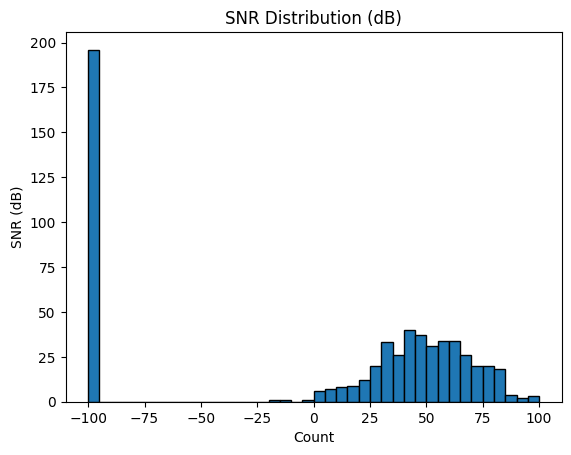

In [45]:
paths = env.computeGeneralPaths(max_depth=2, num_samples=1000000)
snr = env.computeSNR(paths=paths)
cutoff = -100
bin_size = 5
snr_data = np.maximum(snr.flatten(), cutoff)
plt.hist(snr_data, bins=np.arange(np.min(snr_data), np.max(snr_data), bin_size), edgecolor="black")
plt.title("SNR Distribution (dB)")
plt.xlabel("Count")
plt.ylabel("SNR (dB)")
plt.show()

/tmp/ipykernel_47909/2180023914.py:4: RuntimeWarning: divide by zero encountered in log10
  sinr_dB = 10 * np.log10(sinr)


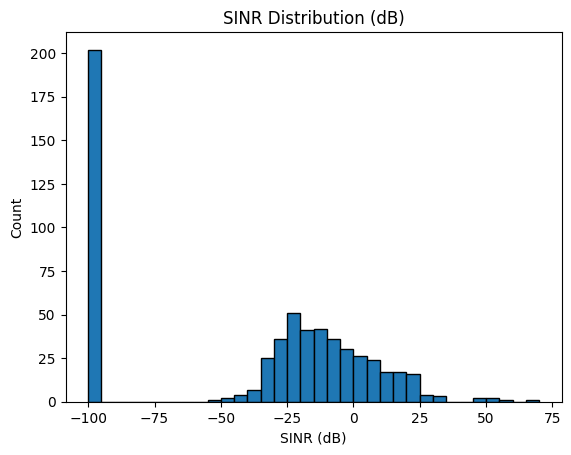

In [46]:
radio_map = env.computeRadioMap(max_depth=2, num_samples=10000000, cell_size=(4.0, 4.0))
sinr = env.getUserSINR(radio_map=radio_map)
# Converting to dB ratio
sinr_dB = 10 * np.log10(sinr)
sinr_dB = np.maximum(sinr_dB, cutoff)

# Visualizing the data distribution
data = sinr_dB.flatten()
plt.hist(sinr_dB.flatten(), bins=np.arange(np.min(data), np.max(data) + bin_size, bin_size), edgecolor="black")
plt.title("SINR Distribution (dB)")
plt.xlabel("SINR (dB)")
plt.ylabel("Count")
plt.show()

### SNR vs. SINR Analysis
* Notice that the distributions are somewhat similar, though the SNR is higher on average than the SINR, which is expected because SINR also consider interference
* The clusters around -100 represent TX-RX pairs with no paths in the SNR case, and Ground Users with no coverage in the SINR case
* I believe that these values are somewhat reasonable for simulation, but they probably require some more validation against real-world data to be sure

# Testing and Visualizing Landmark Matching Functionality
* Given the common use case that you want to assign N UAV devices to N target locations, the assignLandmarks function computes the assignment of landmarks to UAVs that minimizes the maximum travel distance (and thus time) of any UAV
* Assuming the UAVs move in parallel, this minimizes the total time for all UAVs to reach their assigned landmark
* Currently, this model doesn't consider building topology, only strict distance. However, the algorithm holds assuming we can find a function that computes the time between two points with respect to building topology.

In [ ]:
# We currently have 5 UAVs, so we define 5 random landmarks in space and assign the UAVs to them
num_landmarks = len(env.uavs)

# Generating landmarks in a ~ 500 x 500 x 100 box above ground
landmarks = np.random.rand(num_landmarks, 3)
landmarks[:, 2] *= 100
landmarks -= 0.5
landmarks[:, 0] *= 500
landmarks[:, 1] *= 500

# Adding some receivers to show the landmarks in simulation
for i in range(num_landmarks):
    env.scene.add(Receiver(name=f"landmark{i}", position=mi.Point3f(landmarks[i]), color=[0, 0, 0.6]))

print(landmarks)
env.visualize()

In [16]:
# Generating the matching
max_distance, matching = env.assignLandmarks(landmarks)
print(f"The optimal matching has a maximum travel distance of {max_distance} meters.")
for i in range(num_landmarks):
    print(f"UAV {i} at {env.uavs[i].pos} is assigned to landmark {matching[i]} at {landmarks[i]}")

The optimal matching has a maximum travel distance of 414.59332751725634 meters.
UAV 0 at [  0   0 100] is assigned to landmark 4 at [181.36382562 -70.14161492  72.23621891]
UAV 1 at [   0 -500  100] is assigned to landmark 2 at [-178.20057985   98.78300278   34.12124413]
UAV 2 at [500   0 100] is assigned to landmark 0 at [  94.04587392 -101.73759743   33.44130768]
UAV 3 at [  0 500 100] is assigned to landmark 3 at [ 63.13755065 204.47954304  41.96661585]
UAV 4 at [-500    0  100] is assigned to landmark 1 at [-88.26825322   4.32868555  52.88079738]


## Visualizing the Matching
* The bezier paths are computed between each UAV and their respective landmark to minimize time
* These paths are visualized in the simulation to show how the UAVs move to their respective destinations

In [17]:
# Generating some random colors for the paths
colors = np.random.rand(num_landmarks, 3)

for i in range(num_landmarks):
    bezier = env.getBezier(env.uavs[i].pos, landmarks[i], np.zeros(3), np.zeros(3), samples=1000)
    for j in range(len(bezier)):
        env.scene.add(Receiver(name=f"r{i}_{j}", position=mi.Point3f(bezier[j]), color=colors[i] * j / 1000))

# The paths are visualized as lighter over time, so the light end is the terminating side of the path
env.visualize()

# Base Station Functionality
* In addition to UAVs and Ground Users, RL-DT offers support for Base Stations
* Base Stations are like UAVs, except they have no capacity for movement and require few initial parameters. They can be either Receivers or Transmitters
* Base Stations are useful for stationary antennas, and for drawing points of interest in Sionna simulations because they are slightly more removed from the rest of the simulation

In [18]:
# Adding a few Base Stations to the Simulation

bs1 = env.addBaseStation(device_type="tx", pos=np.array([-100, 100, 100]), color=np.random.rand(3), 
                         bandwidth=50, signal_power=2, throughput_capacity=500000000)
bs2 = env.addBaseStation(device_type="tx", pos=np.array([100, -100, 100]), color=np.random.rand(3), 
                         bandwidth=50, signal_power=2, throughput_capacity=500000000)
bs3 = env.addBaseStation(device_type="tx", pos=np.array([-100, -100, 100]), color=np.random.rand(3), 
                         bandwidth=50, signal_power=2, throughput_capacity=500000000)
bs4 = env.addBaseStation(device_type="tx", pos=np.array([100, 100, 100]), color=np.random.rand(3), 
                         bandwidth=50, signal_power=2, throughput_capacity=500000000)

# Visualizing the simulation using the same visualization method
env.visualize()

# AERPAW SINR Calculation Environment
* The goals is to create a minimal environment to simulate AERPAW devices and calculate the SINR values between UAVs, Ground Users, and Base Stations
* Unlike the current AERPAW system, this function will use ray tracing to calculate more realistic paths and incorporate environment data, if provided

## Construction
* This environment will extend the existing environment but provide more direct functionality for computing SINR values between radio devices
* It will also have a more straightforward single configuration where users can input all the devices for the scene at once, and then run their calculations
* Because it extends existing functionality, this class maintains all the movement, computation, and visualization functionality of the standard RL-DT

In [1]:
import numpy as np
from AERPAWEnvironment import AERPAWEnv

# Creating an AERPAW environment using the config dictionaries for UAVs, Base Stations, and Ground Users

uav_config = [{"device_type": "tx",
            "mass": 1,
            "efficiency": 0.8,
            "position": np.array([0, 0, 1]),
            "velocity": np.zeros(3),
            "color": np.array([1, 0, 0]),
            "bandwidth": 50,
            "rotor_area": 2,
            "signal_power": 3,
            "throughput_capacity": 625000000,
            "battery_capacity": 10000}]

gu_config = [{"position": np.zeros(3),
            "velocity": np.zeros(3),
            "bandwidth": 50,
            "device_type": "rx",
            "color": np.array([0, 1, 0]),
            "desired_throughput": 375000}]

bs_config = [{"device_type": "tx",
            "position": np.ones(3),
            "velocity": np.zeros(3),
            "color": np.array([0, 0, 1]),
            "bandwidth": 50,
            "signal_power": 3,
            "throughput_capacity": 625000000,
            "battery_capacity": 10000}]

# Using the default environment, which is a flat reflective surface
aerpaw_env = AERPAWEnv(uavs=uav_config, ground_users=gu_config, base_stations=bs_config)
aerpaw_env.visualize()  # Visualizing using standard functionality

2025-09-07 22:07:38.801747: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-07 22:07:38.812667: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757297258.824855  152162 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757297258.828591  152162 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1757297258.837989  152162 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Visualizing Paths
* We use the standard environment path computation functionality to compute the LoS paths between the three objects
* Then we use the visualize method to draw those paths in the scene

In [2]:
paths = aerpaw_env.computeLOSPaths(mode='gpu')
aerpaw_env.visualize(paths=paths)

## Computing SINR Values
* We compute the SINR values between the UAV, Base Station, and Ground User currently in the simulation
* These are returned in a dictionary with lists the SINR values to each receiver for each transmitter in the simulation

In [3]:
alpha = aerpaw_env.computeAlpha(max_depth=2, num_samples=1000000)[0]
print(alpha)

([[[[[-0.0430074]],
   [[-0.00292838]]]]], [[[[[-0]],
   [[0]]]]])
[-0.04300736 -0.00292838]


In [4]:
import tensorflow as tf
alpha = np.array(alpha)

In [5]:
print(alpha.shape)
print(alpha.squeeze())

(2,)
[-0.04300736 -0.00292838]


In [6]:
data_rate = aerpaw_env.computeGeneralDataRate()

([[[[[-0.0430074]],
   [[-0.00292838]]]]], [[[[[-0]],
   [[0]]]]])


I0000 00:00:1757297261.776816  152162 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4114 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
2025-09-07 22:07:41.836785: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at strided_slice_op.cc:117 : INVALID_ARGUMENT: slice index 2 of dimension 0 out of bounds.
2025-09-07 22:07:41.836801: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: INVALID_ARGUMENT: slice index 2 of dimension 0 out of bounds.


InvalidArgumentError: {{function_node __wrapped__StridedSlice_device_/job:localhost/replica:0/task:0/device:GPU:0}} slice index 2 of dimension 0 out of bounds. [Op:StridedSlice] name: strided_slice/